# Notebook 09 — SIR Epidemic Simulation

**Goal**: Run a multi-county SIR model for seasonal influenza, where each county's transmission rate β is scaled by the ML-predicted outbreak vulnerability from the Random Forest production model.

**Spatial coupling**: inter-county spread via the US Census county adjacency file (shared-border neighbours only).

**Policy levers**:
- `vax_boost` — additional vaccination coverage applied on top of observed baseline
- `mobility_factor` — scales inter-county transmission (1 = baseline, 0 = complete isolation)

**Outputs** saved to `models/`:
- `sir_epidemic_curves.png` — per-county + state-aggregate epidemic curves
- `sir_county_peaks.png` — peak infection rate by county + ML correlation
- `sir_policy_comparison.png` — 6 policy scenario comparison
- `sir_results.json` — full county parameters + simulation results for Flask frontend

## 1  Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import requests
import warnings
from collections import defaultdict
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH   = '../data/processed/master_stacked.csv'
FEAT_PATH   = '../data/processed/selected_features.json'
MODEL_PATH  = '../models/rf_model.pkl'
SCALER_PATH = '../models/rf_scaler.pkl'

# Flu-specific epidemiological constants
GAMMA     = 1 / 7      # recovery rate (7-day infectious period)
R0_BASE   = 1.3        # baseline reproduction number for seasonal flu
BETA_BASE = R0_BASE * GAMMA  # ≈ 0.186
ML_SCALE  = 0.5        # high-risk counties can have up to 50 % higher β
ALPHA     = 0.02       # inter-county coupling strength
T_SIM     = 180        # simulation horizon (days)
SEED_N    = 10         # initial infections in seeded counties

STATE_COLORS = {'NY': 'steelblue', 'PA': 'forestgreen', 'CT': 'darkorange', 'DE': 'crimson'}

print(f"β_base = {BETA_BASE:.4f}   γ = {GAMMA:.4f}   R0_base = {R0_BASE}")

/Users/clenath24/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


β_base = 0.1857   γ = 0.1429   R0_base = 1.3


## 2  Load data and production model

In [2]:
df = pd.read_csv(DATA_PATH)
with open(FEAT_PATH) as fh:
    feat_cfg   = json.load(fh)
    features   = feat_cfg['all']
    demo_feats = feat_cfg['demographic']
with open(MODEL_PATH, 'rb') as fh:
    artifact = pickle.load(fh)
    model  = artifact['model']
    iso    = artifact['isotonic_calibrator']
    scaler = artifact['scaler']

print(f"Dataset: {df.shape}  |  Features ({len(features)}): {features}")
print(f"Diseases: {df['disease'].value_counts().to_dict()}")


Dataset: (357, 40)  |  Features (10): ['pct_foreign_born', 'pop_density_per_sqmi', 'avg_household_size', 'public_transport_pct', 'pct_elderly', 'disease_FLU', 'disease_RSV', 'state_DE', 'state_NY', 'state_PA']
Diseases: {'FLU': 141, 'COVID': 140, 'RSV': 76}


## 3  Generate ML predictions for flu counties

In [3]:
flu = df[df['disease'] == 'FLU'].copy().reset_index(drop=True)
flu['fips_str'] = flu['fips'].astype(str).str.zfill(5)

# Scale only the demographic features (in the order the scaler was trained on)
demo_cols      = list(scaler.feature_names_in_)
disease_dummy_cols = [c for c in features if c.startswith('disease_')]
state_dummy_cols   = [c for c in features if c.startswith('state_')]

disease_X = pd.get_dummies(flu['disease'], prefix='disease').reindex(
    columns=disease_dummy_cols, fill_value=0).astype(float)
state_X   = pd.get_dummies(flu['state'],   prefix='state').reindex(
    columns=state_dummy_cols,   fill_value=0).astype(float)

demo_scaled = pd.DataFrame(
    scaler.transform(flu[demo_cols]),
    columns=demo_cols, index=flu.index
)
flu_X = pd.concat([demo_scaled, disease_X, state_X], axis=1)[features]

raw_proba         = model.predict_proba(flu_X.to_numpy())[:, 1]
flu['p_outbreak'] = iso.predict(raw_proba)

print(f"Flu counties: {len(flu)}")
print(f"\nTop 10 by P(outbreak):")
print(
    flu[['state', 'county', 'p_outbreak', 'pct_vaccinated', 'pop_total']]
    .sort_values('p_outbreak', ascending=False)
    .head(10)
    .to_string(index=False)
)


Flu counties: 141

Top 10 by P(outbreak):
state      county  p_outbreak  pct_vaccinated  pop_total
   NY      QUEENS    1.000000            80.1    2360826
   NY       BRONX    1.000000            67.5    1443229
   PA      FULTON    0.916667            33.9      14545
   NY    RICHMOND    0.916667            68.6     492925
   NY      NASSAU    0.916667            76.5    1389160
   NY WESTCHESTER    0.916667            75.8     997904
   NY       KINGS    0.916667            66.2    2679620
   NY    NEW YORK    0.898003            80.7    1645867
   NY    ROCKLAND    0.700000            60.1     337326
   PA     MONTOUR    0.700000            74.7      18165


## 4  Per-county SIR parameters

Transmission rate: `β_i = β_base × (1 + ML_SCALE × P(outbreak)_i)`

Initial conditions:
- **R_init** = population × vaccination coverage  (pre-immune)
- **I_init** = 0 for all counties except the 3 highest-risk, which are seeded with `SEED_N` infections
- **S_init** = N − R_init − I_init

In [4]:
flu['beta']   = BETA_BASE * (1 + ML_SCALE * flu['p_outbreak'])
flu['gamma']  = GAMMA
flu['N']      = flu['pop_total'].astype(float)
flu['V0']     = (flu['pct_vaccinated'].clip(0, 100) / 100)  # baseline vax fraction

# Seed the 3 highest-risk counties
flu['I_init'] = 0.0
top3_idx = flu.nlargest(3, 'p_outbreak').index
flu.loc[top3_idx, 'I_init'] = float(SEED_N)

flu['R_init'] = flu['N'] * flu['V0']                          # pre-immune from vaccination
flu['S_init'] = (flu['N'] - flu['R_init'] - flu['I_init']).clip(lower=0)

print(f"β range:  [{flu['beta'].min():.4f}, {flu['beta'].max():.4f}]")
print(f"R_eff range (β/γ): [{(flu['beta']/GAMMA).min():.2f}, {(flu['beta']/GAMMA).max():.2f}]")
print(f"\nSeeded counties:")
print(flu.loc[top3_idx, ['county', 'state', 'p_outbreak', 'I_init']].to_string(index=False))

β range:  [0.1923, 0.2786]
R_eff range (β/γ): [1.35, 1.95]

Seeded counties:
county state  p_outbreak  I_init
 BRONX    NY    1.000000    10.0
QUEENS    NY    1.000000    10.0
 KINGS    NY    0.916667    10.0


## 5  County adjacency from US Census

In [5]:
ADJ_URL = 'https://www2.census.gov/geo/docs/reference/county_adjacency.txt'
print(f"Fetching adjacency file …")
resp = requests.get(ADJ_URL, timeout=30)
resp.raise_for_status()
print(f"Downloaded {len(resp.content) / 1024:.0f} KB")

# Parse the fixed-width / tab-delimited format:
# col 0 = county name (blank if same county as previous row)
# col 1 = county FIPS
# col 2 = neighbour name
# col 3 = neighbour FIPS
edges = []
current_fips = None
for line in resp.text.strip().split('\n'):
    parts = line.split('\t')
    if len(parts) < 4:
        continue
    fips_col = parts[1].strip().strip('"').zfill(5) if parts[1].strip() else None
    nb_fips  = parts[3].strip().strip('"').zfill(5) if parts[3].strip() else None
    if fips_col:
        current_fips = fips_col
    if current_fips and nb_fips and current_fips != nb_fips:
        edges.append((current_fips, nb_fips))

adj_us = pd.DataFrame(edges, columns=['fips_a', 'fips_b'])
print(f"Total edges in US: {len(adj_us):,}")

# Filter to our 4-state counties
our_fips = set(flu['fips_str'])
mask = adj_us['fips_a'].isin(our_fips) & adj_us['fips_b'].isin(our_fips)
adj_local = adj_us[mask].copy()
print(f"Edges within NY/PA/CT/DE: {len(adj_local)}")

adj_dict = defaultdict(list)
for _, row in adj_local.iterrows():
    adj_dict[row['fips_a']].append(row['fips_b'])
    adj_dict[row['fips_b']].append(row['fips_a'])

covered  = our_fips & set(adj_dict.keys())
isolated = our_fips - covered
print(f"Counties with ≥1 regional neighbour: {len(covered)} / {len(our_fips)}")
if isolated:
    iso_names = flu[flu['fips_str'].isin(isolated)][['county', 'state']].values
    print(f"No regional border (spread locally only): {iso_names}")

Fetching adjacency file …


Downloaded 710 KB
Total edges in US: 18,966
Edges within NY/PA/CT/DE: 678
Counties with ≥1 regional neighbour: 132 / 141
No regional border (spread locally only): [['CAPITOL' 'CT']
 ['GREATER BRIDGEPORT' 'CT']
 ['LOWER CONNECTICUT RIVER VALLEY' 'CT']
 ['NAUGATUCK VALLEY' 'CT']
 ['NORTHEASTERN CONNECTICUT' 'CT']
 ['NORTHWEST HILLS' 'CT']
 ['SOUTH CENTRAL CONNECTICUT' 'CT']
 ['SOUTHEASTERN CONNECTICUT' 'CT']
 ['WESTERN CONNECTICUT' 'CT']]


## 6  Multi-county SIR ODE system

State vector: `[S_0, I_0, R_0, S_1, I_1, R_1, …]` — 3 slots per county.

Force of infection on county *i*:
```
λ_i = β_i · I_i/N_i  +  α · mobility · Σ_{j ∈ neighbours(i)} I_j/N_j
```

In [6]:
def _build_ode(beta_arr, gamma_arr, N_arr, adj_pairs, alpha, mobility_factor):
    """Return an ODE RHS for scipy.integrate.solve_ivp."""
    eff_alpha = alpha * mobility_factor

    def rhs(t, y):
        S = y[0::3]
        I = y[1::3]

        local_foi = beta_arr * I / N_arr

        imported = np.zeros(len(N_arr))
        for (i, j) in adj_pairs:
            imported[i] += I[j] / N_arr[j]
        imported *= eff_alpha

        foi = local_foi + imported
        dS  = -foi * S
        dI  =  foi * S - gamma_arr * I
        dR  =  gamma_arr * I

        out = np.empty_like(y)
        out[0::3] = dS
        out[1::3] = dI
        out[2::3] = dR
        return out

    return rhs


def run_simulation(flu_df, adj, T=T_SIM,
                   vax_boost=0.0, mobility_factor=1.0, alpha=ALPHA):
    """
    Multi-county SIR simulation.

    Parameters
    ----------
    vax_boost        : additional vaccination fraction added to baseline (0–1)
    mobility_factor  : scales inter-county coupling α (0 = isolation, 1 = baseline)

    Returns dict with 't', 'S', 'I', 'R' (shape n_counties × n_timepoints),
    'N', 'fips_order', 'peak_infected_pct', 'peak_day'.
    """
    fips_order = flu_df['fips_str'].tolist()
    fips_idx   = {f: i for i, f in enumerate(fips_order)}
    n = len(fips_order)

    _df = flu_df.set_index('fips_str')
    beta_arr  = _df['beta'].reindex(fips_order).values
    gamma_arr = _df['gamma'].reindex(fips_order).values
    N_arr     = _df['N'].reindex(fips_order).values
    V0_arr    = _df['V0'].reindex(fips_order).values
    I0_arr    = _df['I_init'].reindex(fips_order).values

    # Apply vaccination boost
    vax_eff = np.clip(V0_arr + vax_boost, 0, 1)
    R_init  = N_arr * vax_eff
    S_init  = np.clip(N_arr - R_init - I0_arr, 0, None)

    y0 = np.zeros(3 * n)
    y0[0::3] = S_init
    y0[1::3] = I0_arr
    y0[2::3] = R_init

    adj_pairs = [
        (fips_idx[a], fips_idx[b])
        for a, neighbours in adj.items()
        for b in neighbours
        if a in fips_idx and b in fips_idx
    ]

    rhs = _build_ode(beta_arr, gamma_arr, N_arr, adj_pairs, alpha, mobility_factor)
    t_eval = np.linspace(0, T, T * 2 + 1)  # 0.5-day resolution

    sol = solve_ivp(rhs, [0, T], y0, method='RK45',
                    t_eval=t_eval, rtol=1e-4, atol=1e-6)

    S = sol.y[0::3]   # (n, n_timepoints)
    I = sol.y[1::3]
    R = sol.y[2::3]

    I_rate = I / N_arr[:, None]

    return {
        't':                 sol.t,
        'S': S, 'I': I, 'R': R,
        'N':                 N_arr,
        'fips_order':        fips_order,
        'peak_infected_pct': I_rate.max(axis=1) * 100,
        'peak_day':          sol.t[I_rate.argmax(axis=1)],
    }


print("SIR ODE system ready.")

SIR ODE system ready.


## 7  Baseline simulation

In [7]:
print("Running baseline simulation …")
baseline = run_simulation(flu, adj_dict)
print(f"Done. Time points: {len(baseline['t'])}")

fips_to_state  = flu.set_index('fips_str')['state'].to_dict()
fips_to_county = flu.set_index('fips_str')['county'].to_dict()
fips_to_p      = flu.set_index('fips_str')['p_outbreak'].to_dict()

peak_df = pd.DataFrame({
    'fips':              baseline['fips_order'],
    'peak_infected_pct': baseline['peak_infected_pct'],
    'peak_day':          baseline['peak_day'],
    'p_outbreak':        [fips_to_p[f] for f in baseline['fips_order']],
    'state':             [fips_to_state[f]  for f in baseline['fips_order']],
    'county':            [fips_to_county[f] for f in baseline['fips_order']],
})

print("\nTop 10 counties by peak infection rate:")
print(
    peak_df.sort_values('peak_infected_pct', ascending=False)
    .head(10)[['county', 'state', 'p_outbreak', 'peak_infected_pct', 'peak_day']]
    .to_string(index=False)
)

I_total = baseline['I'].sum(axis=0)
N_total = baseline['N'].sum()
print(f"\nAggregate peak: {I_total.max() / N_total * 100:.2f}% of region infected simultaneously")
print(f"Total infected by day {T_SIM}: {baseline['R'][:, -1].sum() / N_total * 100:.1f}%")

Running baseline simulation …
Done. Time points: 361

Top 10 counties by peak infection rate:
        county state  p_outbreak  peak_infected_pct  peak_day
        POTTER    PA    0.217391           0.002925     180.0
      LYCOMING    PA    0.217391           0.002128     180.0
       CLINTON    PA    0.193878           0.001955     180.0
      BRADFORD    PA    0.241379           0.001805     180.0
         TIOGA    PA    0.217391           0.001775     180.0
       JUNIATA    PA    0.217391           0.001584     180.0
NORTHUMBERLAND    PA    0.700000           0.001345     180.0
      ALLEGANY    NY    0.193878           0.001330     180.0
        FULTON    PA    0.916667           0.001280     180.0
        MCKEAN    PA    0.193878           0.001274     180.0

Aggregate peak: 0.00% of region infected simultaneously
Total infected by day 180: 66.7%


## 8  Visualisation — epidemic curves by state

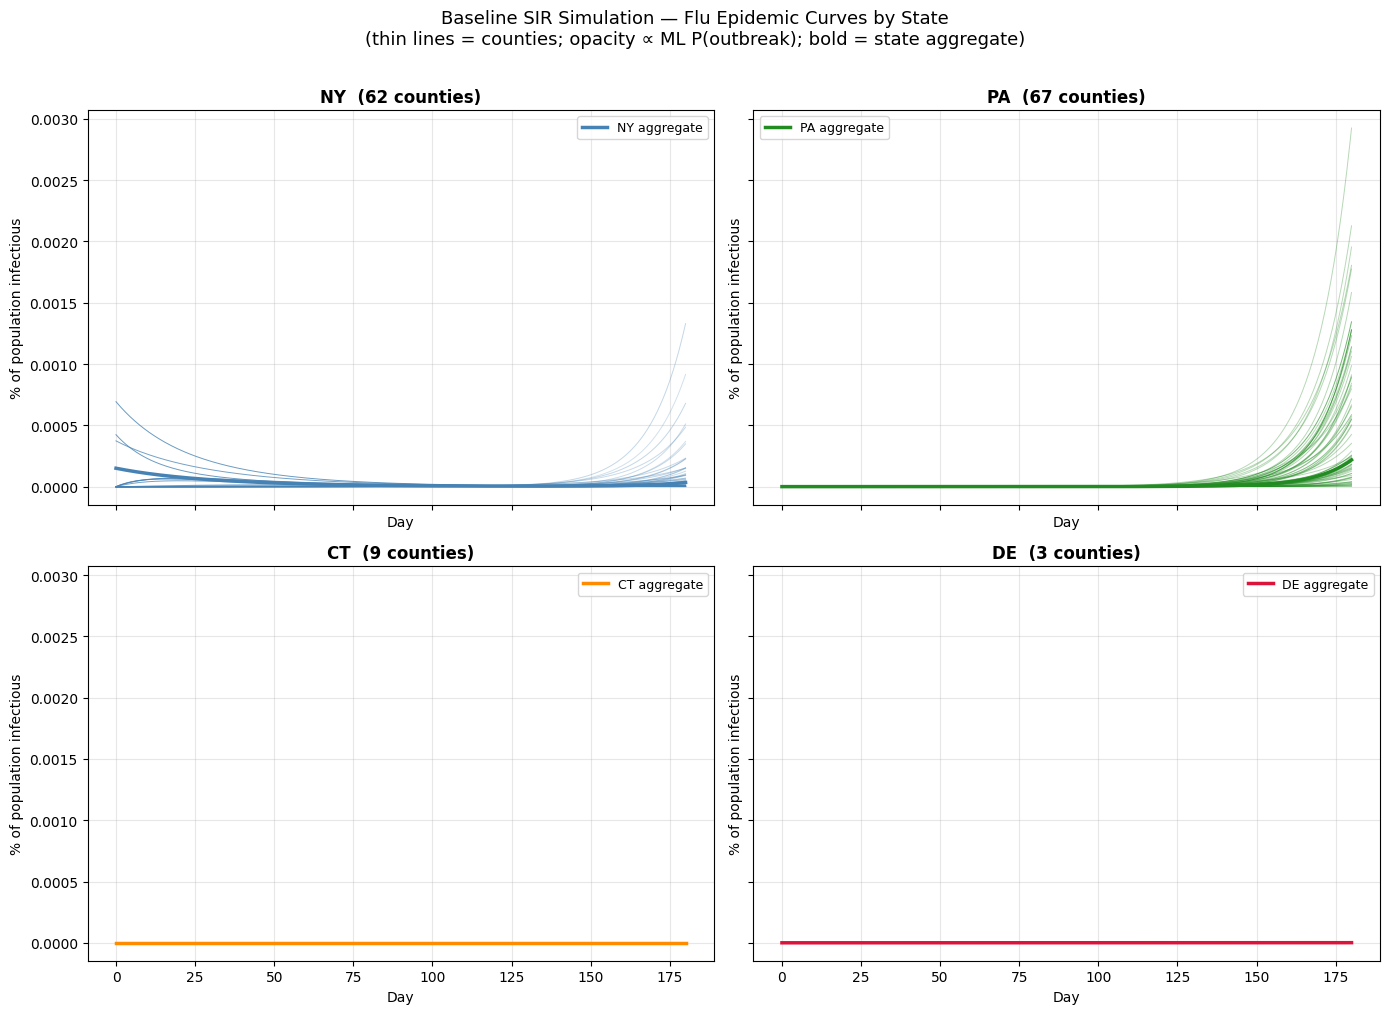

Saved: sir_epidemic_curves.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, state in zip(axes.flat, ['NY', 'PA', 'CT', 'DE']):
    color = STATE_COLORS[state]
    state_fips = [f for f in baseline['fips_order'] if fips_to_state[f] == state]
    idx = [baseline['fips_order'].index(f) for f in state_fips]

    I_pct = baseline['I'][idx] / baseline['N'][idx, None] * 100
    t     = baseline['t']

    for i, fips in enumerate(state_fips):
        a = 0.2 + 0.6 * fips_to_p[fips]
        ax.plot(t, I_pct[i], color=color, alpha=a, linewidth=0.7)

    # State aggregate
    I_agg = baseline['I'][idx].sum(axis=0)
    N_agg = baseline['N'][idx].sum()
    ax.plot(t, I_agg / N_agg * 100, color=color, linewidth=2.5,
            label=f'{state} aggregate', zorder=5)

    ax.set_title(f'{state}  ({len(state_fips)} counties)', fontsize=12, fontweight='bold')
    ax.set_ylabel('% of population infectious')
    ax.set_xlabel('Day')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Baseline SIR Simulation — Flu Epidemic Curves by State\n'
    '(thin lines = counties; opacity ∝ ML P(outbreak); bold = state aggregate)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('../models/sir_epidemic_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_epidemic_curves.png")

## 9  Visualisation — county peak infection rates

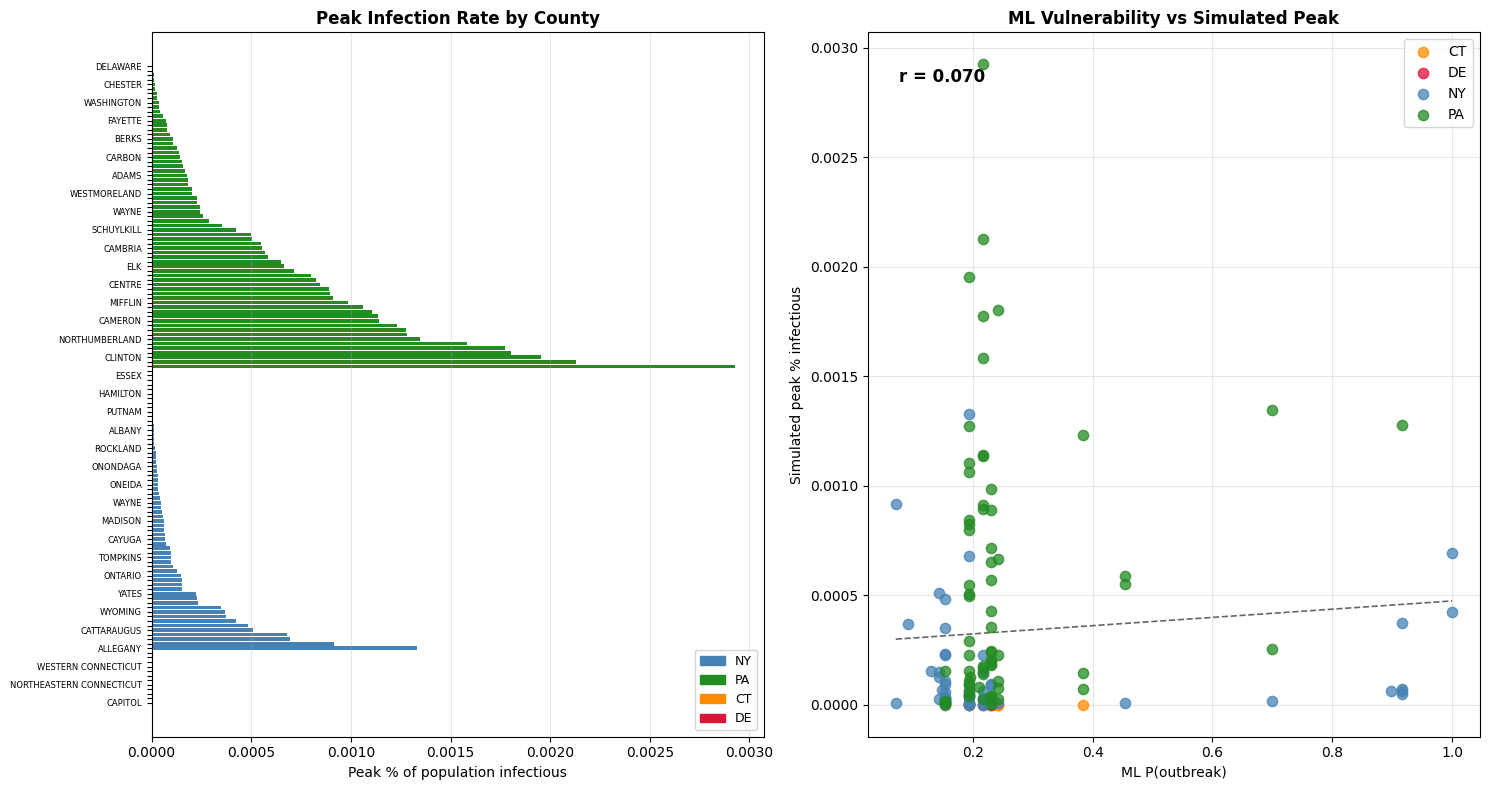

Saved: sir_county_peaks.png


In [9]:
peak_sorted = peak_df.sort_values(['state', 'peak_infected_pct'], ascending=[True, False])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# --- left: horizontal bar chart ---
ax = axes[0]
bar_colors = [STATE_COLORS[s] for s in peak_sorted['state']]
ax.barh(range(len(peak_sorted)), peak_sorted['peak_infected_pct'],
        color=bar_colors, edgecolor='none', height=0.8)
ax.set_yticks(range(len(peak_sorted)))
labels = [
    row.county.replace(' County', '').replace(' Planning Region', '')
    if i % 4 == 0 else ''
    for i, row in enumerate(peak_sorted.itertuples())
]
ax.set_yticklabels(labels, fontsize=6)
ax.set_xlabel('Peak % of population infectious')
ax.set_title('Peak Infection Rate by County', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in STATE_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# --- right: ML P(outbreak) vs simulated peak ---
ax2 = axes[1]
for state, grp in peak_df.groupby('state'):
    ax2.scatter(grp['p_outbreak'], grp['peak_infected_pct'],
                label=state, color=STATE_COLORS[state], alpha=0.75, s=55, zorder=3)

r = np.corrcoef(peak_df['p_outbreak'], peak_df['peak_infected_pct'])[0, 1]
m, b = np.polyfit(peak_df['p_outbreak'], peak_df['peak_infected_pct'], 1)
x_line = np.linspace(peak_df['p_outbreak'].min(), peak_df['p_outbreak'].max(), 50)
ax2.plot(x_line, m * x_line + b, 'k--', linewidth=1.2, alpha=0.6)
ax2.text(0.05, 0.95, f'r = {r:.3f}', transform=ax2.transAxes,
         fontsize=12, va='top', fontweight='bold')
ax2.set_xlabel('ML P(outbreak)')
ax2.set_ylabel('Simulated peak % infectious')
ax2.set_title('ML Vulnerability vs Simulated Peak', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/sir_county_peaks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_county_peaks.png")

## 10  Policy intervention scenarios

In [10]:
SCENARIOS = {
    'Baseline':            {'vax_boost': 0.00, 'mobility_factor': 1.00},
    '+10% vaccination':    {'vax_boost': 0.10, 'mobility_factor': 1.00},
    '+20% vaccination':    {'vax_boost': 0.20, 'mobility_factor': 1.00},
    'Mobility −25%':       {'vax_boost': 0.00, 'mobility_factor': 0.75},
    'Mobility −50%':       {'vax_boost': 0.00, 'mobility_factor': 0.50},
    '+10% vax + mob −25%': {'vax_boost': 0.10, 'mobility_factor': 0.75},
}

print("Running policy scenarios …")
scenario_results = {}
for name, params in SCENARIOS.items():
    res = run_simulation(flu, adj_dict, **params)
    I_agg = res['I'].sum(axis=0)
    N_tot = res['N'].sum()
    scenario_results[name] = {
        'results':            res,
        'total_peak_pct':     float(I_agg.max() / N_tot * 100),
        'total_infected_pct': float(res['R'][:, -1].sum() / N_tot * 100),
        'peak_day':           float(res['t'][np.argmax(I_agg)]),
        'params':             params,
    }
    print(
        f"  {name:<28} peak={scenario_results[name]['total_peak_pct']:5.2f}%  "
        f"total_infected={scenario_results[name]['total_infected_pct']:5.1f}%  "
        f"peak_day={scenario_results[name]['peak_day']:.0f}"
    )
print("Done.")

Running policy scenarios …
  Baseline                     peak= 0.00%  total_infected= 66.7%  peak_day=180
  +10% vaccination             peak= 0.00%  total_infected= 76.7%  peak_day=0
  +20% vaccination             peak= 0.00%  total_infected= 86.7%  peak_day=0
  Mobility −25%                peak= 0.00%  total_infected= 66.7%  peak_day=0
  Mobility −50%                peak= 0.00%  total_infected= 66.7%  peak_day=0
  +10% vax + mob −25%          peak= 0.00%  total_infected= 76.7%  peak_day=0
Done.


## 11  Visualisation — policy comparison

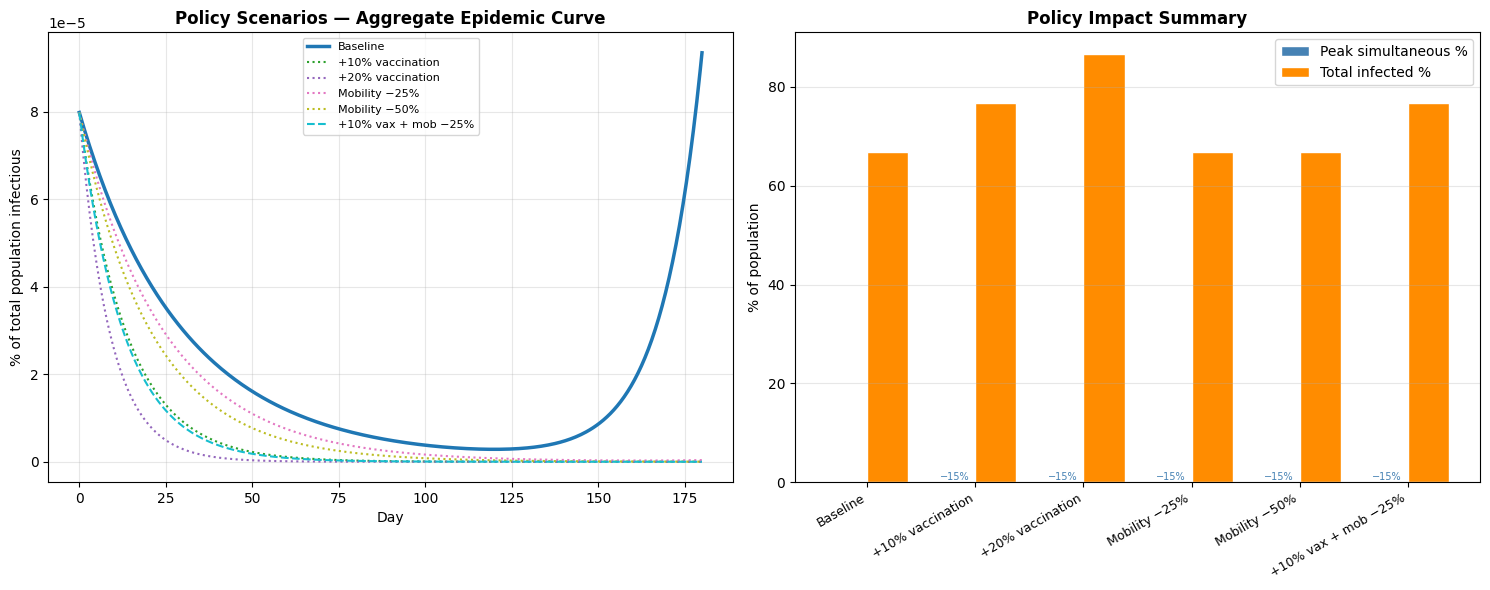

Saved: sir_policy_comparison.png


In [11]:
palette = plt.cm.tab10(np.linspace(0, 1, len(SCENARIOS)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left: epidemic curves ---
ax = axes[0]
for (name, sr), color in zip(scenario_results.items(), palette):
    r   = sr['results']
    I_a = r['I'].sum(axis=0) / r['N'].sum() * 100
    lw  = 2.5 if name == 'Baseline' else 1.5
    ls  = '-' if name == 'Baseline' else ('--' if 'vax' in name else ':')
    ax.plot(r['t'], I_a, color=color, linewidth=lw, linestyle=ls, label=name)

ax.set_xlabel('Day')
ax.set_ylabel('% of total population infectious')
ax.set_title('Policy Scenarios — Aggregate Epidemic Curve', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- right: bar summary ---
ax2  = axes[1]
names  = list(scenario_results.keys())
x      = np.arange(len(names))
w      = 0.38
peaks  = [scenario_results[n]['total_peak_pct']    for n in names]
totals = [scenario_results[n]['total_infected_pct'] for n in names]

ax2.bar(x - w/2, peaks,  w, label='Peak simultaneous %', color='steelblue',  edgecolor='white')
ax2.bar(x + w/2, totals, w, label='Total infected %',     color='darkorange', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('% of population')
ax2.set_title('Policy Impact Summary', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Annotate % reduction vs baseline on peak bars
base_peak = scenario_results['Baseline']['total_peak_pct']
for i, (name, val) in enumerate(zip(names, peaks)):
    if name != 'Baseline':
        pct_red = (base_peak - val) / base_peak * 100
        ax2.text(i - w/2, val + 0.02, f'−{pct_red:.0f}%',
                 ha='center', va='bottom', fontsize=7, color='steelblue')

plt.tight_layout()
plt.savefig('../models/sir_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sir_policy_comparison.png")

## 12  Export results for Flask frontend

Writes `models/sir_results.json` with:
- `metadata` — model provenance, epidemiological constants
- `counties` — per-county params + baseline I(t) time series (sampled every 2 days)
- `adjacency` — list of `[fips_a, fips_b]` pairs for the region
- `scenarios` — summary stats for all 6 policy scenarios

In [12]:
# Subsample time series: every 4th point (0.5-day res → 2-day res)
t_sub = baseline['t'][::4].tolist()

county_records = []
for i, fips in enumerate(baseline['fips_order']):
    row = flu[flu['fips_str'] == fips].iloc[0]
    county_records.append({
        'fips':              fips,
        'county':            row['county'],
        'state':             row['state'],
        'pop_total':         int(row['N']),
        'pct_vaccinated':    round(float(row['V0'] * 100), 1),
        'p_outbreak':        round(float(row['p_outbreak']), 4),
        'beta':              round(float(row['beta']), 5),
        'gamma':             round(float(GAMMA), 5),
        'peak_infected_pct': round(float(baseline['peak_infected_pct'][i]), 3),
        'peak_day':          round(float(baseline['peak_day'][i]), 1),
        'I_series':          [round(v, 2) for v in baseline['I'][i, ::4].tolist()],
        't_series':          [round(v, 1) for v in t_sub],
    })

out = {
    'metadata': {
        'production_model':  'RandomForest',
        'pr_auc':            0.5064,
        'gamma':             GAMMA,
        'R0_base':           R0_BASE,
        'beta_base':         round(BETA_BASE, 5),
        'ML_scale':          ML_SCALE,
        'alpha':             ALPHA,
        'T_days':            T_SIM,
        'seed_n':            SEED_N,
        'n_counties':        len(county_records),
    },
    'counties':  county_records,
    'adjacency': adj_local[['fips_a', 'fips_b']].values.tolist(),
    'scenarios': {
        name: {
            'params':             sr['params'],
            'total_peak_pct':     round(sr['total_peak_pct'],     3),
            'total_infected_pct': round(sr['total_infected_pct'], 1),
            'peak_day':           round(sr['peak_day'],           1),
        }
        for name, sr in scenario_results.items()
    },
}

with open('../models/sir_results.json', 'w') as fh:
    json.dump(out, fh, indent=2)

print(f"Exported sir_results.json")
print(f"  {len(county_records)} counties  |  {len(adj_local)} adjacency pairs  |  {len(SCENARIOS)} scenarios")
print("\nNotebook 09 complete.")

Exported sir_results.json
  141 counties  |  678 adjacency pairs  |  6 scenarios

Notebook 09 complete.
